In [9]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn.pipeline import Pipeline # Biblioteca para Pipeline
from sklearn.preprocessing import StandardScaler # Biblioteca para pré processamento
from sklearn.linear_model import LinearRegression #Biblioteca de regressão linear
from sklearn.model_selection import learning_curve, LearningCurveDisplay #Biblioteca de aprendizado
from sklearn.metrics import (
    mean_absolute_error, 
    mean_squared_error,  
    PredictionErrorDisplay,
    root_mean_squared_error,
    r2_score # Métricas
)

from sklearn.model_selection import train_test_split #Trainar e testar o modelo

from src.auxiliares import dataframe_coeficientes
from src.config import DADOS_TRATADOS
from src.graficos import plot_coeficientes, plot_residuos
#scripts para melhorar a eficiência.

sns.set_theme(palette="bright")

RANDOM_STATE = 42 #Dessa forma, teremos os mesmos resultados.

In [11]:
df = pd.read_parquet(DADOS_TRATADOS)

df.head()

,idade,sexo,imc,pressao_media,colesterol_total,ldl,hdl,colesterol_hdl,triglicerides,glicose,target
0,59,2,32.099998,101.0,157,93.199997,38.0,4.0,4.8598,87,151
1,48,1,21.600000,87.0,183,103.199997,70.0,3.0,3.8918,69,75
2,72,2,30.500000,93.0,156,93.599998,41.0,4.0,4.6728,85,141
3,24,1,25.299999,84.0,198,131.399994,40.0,5.0,4.8903,89,206
4,50,1,23.000000,101.0,192,125.400002,52.0,4.0,4.2905,80,135


In [13]:
X = df.drop(columns="target")
y = df["target"] 

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

pipeline = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("reg", LinearRegression())
    ]
)

# Feitos as etapas do pipeline

In [25]:
pipeline.fit(X_train, y_train)

# Feito o treino e o teste, seguindo a ordem que fizemos no pipeline.

Pipeline(steps=[('scaler', StandardScaler()), ('reg', LinearRegression())])

In [27]:
pipeline.score(X_test, y_test)

0.452602744102478

In [29]:
pipeline.named_steps # Atributo para indicar as etapas

{'scaler': StandardScaler(), 'reg': LinearRegression()}

In [33]:
pipeline["reg"].coef_ #Forma de acessar os coeficientes (métricas) do modelo treinado, de acordo com a etapa "reg" do pipeline.

array([  1.7537615, -11.511821 ,  25.607111 ,  16.828888 , -44.44886  ,
        24.640951 ,   7.6769834,  13.138799 ,  35.16119  ,   2.3513749],
      dtype=float32)

In [35]:
pipeline["reg"].intercept_

np.float32(153.73654)

In [39]:
coefs = dataframe_coeficientes(
    pipeline["reg"].coef_,
    X.columns
)

coefs

,coeficiente
colesterol_total,-44.448860
sexo,-11.511821
idade,1.753762
glicose,2.351375
hdl,7.676983
colesterol_hdl,13.138799
pressao_media,16.828888
ldl,24.640951
imc,25.607111
triglicerides,35.161190


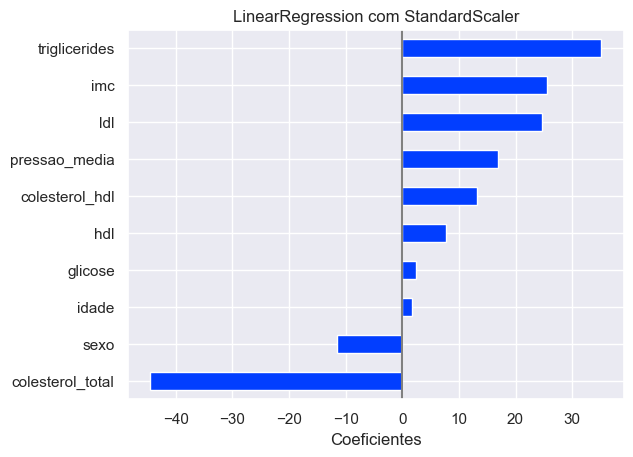

In [43]:
plot_coeficientes(coefs, "LinearRegression com StandardScaler")

# Agora com o ajuste de escala, melhoramos os dados. 